In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

## Load Dataset

In [2]:
DATA_DIR = Path(".")

In [4]:
print(DATA_DIR.exists())
print(list(DATA_DIR.iterdir()))

True
[PosixPath('Project ML_progress.ipynb'), PosixPath('weather_train.csv'), PosixPath('train.csv'), PosixPath('README.md'), PosixPath('building_metadata.csv')]


In [5]:
path_train = DATA_DIR / "train.csv"
path_building = DATA_DIR / "building_metadata.csv"
path_weather = DATA_DIR / "weather_train.csv"

In [6]:
train_df = pd.read_csv(path_train)
building_df = pd.read_csv(path_building)
weather_df = pd.read_csv(path_weather)

In [7]:
print("Train:", train_df.shape)
print("Building:", building_df.shape)
print("Weather:", weather_df.shape)

Train: (20216100, 4)
Building: (1449, 6)
Weather: (139773, 9)


## Reduce memory

In [8]:
def reduce_mem_usage(df, verbose=True):

    numerics = [
        'int16', 'int32', 'int64',
        'float32', 'float64'
    ]

    start_mem = df.memory_usage().sum() / 1024**2

    for col in df.columns:

        col_type = df[col].dtypes

        if col_type in numerics:

            c_min = df[col].min()
            c_max = df[col].max()

            # integer
            if str(col_type)[:3] == 'int':

                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)

                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)

                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)

            # float
            else:

                if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)

        end_mem = df.memory_usage().sum() / 1024**2

    if verbose:
        print(
            'Memory usage decreased to {:5.2f} Mb ({:.1f}% reduction)'
            .format(end_mem,
                    100 * (start_mem - end_mem) / start_mem)
        )

    return df

In [9]:
train_df = reduce_mem_usage(train_df)
building_df = reduce_mem_usage(building_df)
weather_df = reduce_mem_usage(weather_df)

Memory usage decreased to 289.19 Mb (53.1% reduction)
Memory usage decreased to  0.03 Mb (52.0% reduction)
Memory usage decreased to  4.93 Mb (48.6% reduction)


In [10]:
print("Train:", train_df.shape)
print("Building:", building_df.shape)
print("Weather:", weather_df.shape)

Train: (20216100, 4)
Building: (1449, 6)
Weather: (139773, 9)


## Merge Dataset

In [11]:
train_df.head()

,building_id,meter,timestamp,meter_reading
0,0,0,2016-01-01 00:00:00,0.0
1,1,0,2016-01-01 00:00:00,0.0
2,2,0,2016-01-01 00:00:00,0.0
3,3,0,2016-01-01 00:00:00,0.0
4,4,0,2016-01-01 00:00:00,0.0


In [12]:
building_df.head()

,site_id,building_id,primary_use,square_feet,year_built,floor_count
0,0,0,Education,7432,2008.0,NaN
1,0,1,Education,2720,2004.0,NaN
2,0,2,Education,5376,1991.0,NaN
3,0,3,Education,23685,2002.0,NaN
4,0,4,Education,116607,1975.0,NaN


In [13]:
weather_df.head()

,site_id,timestamp,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
0,0,2016-01-01 00:00:00,25.000000,6.0,20.0,NaN,1019.700012,0.0,0.0
1,0,2016-01-01 01:00:00,24.400000,NaN,21.1,-1.0,1020.200012,70.0,1.5
2,0,2016-01-01 02:00:00,22.799999,2.0,21.1,0.0,1020.200012,0.0,0.0
3,0,2016-01-01 03:00:00,21.100000,2.0,20.6,0.0,1020.099976,0.0,0.0
4,0,2016-01-01 04:00:00,20.000000,2.0,20.0,-1.0,1020.000000,250.0,2.6


In [14]:
train_df = train_df[train_df["meter"] == 0]

print(train_df.shape)

(12060910, 4)


In [15]:
df_full = train_df.merge(
    building_df,
    on='building_id',
    how='left'
)

print(df_full.shape)
df_full.head()

(12060910, 9)


,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,floor_count
0,0,0,2016-01-01 00:00:00,0.0,0,Education,7432,2008.0,NaN
1,1,0,2016-01-01 00:00:00,0.0,0,Education,2720,2004.0,NaN
2,2,0,2016-01-01 00:00:00,0.0,0,Education,5376,1991.0,NaN
3,3,0,2016-01-01 00:00:00,0.0,0,Education,23685,2002.0,NaN
4,4,0,2016-01-01 00:00:00,0.0,0,Education,116607,1975.0,NaN


In [16]:
df_full = df_full.merge(
    weather_df,
    on=['site_id', 'timestamp'],
    how='left'
)

## EDA

In [17]:
print(df_full.shape)
print(df_full.info())

(12060910, 16)
<class 'pandas.DataFrame'>
RangeIndex: 12060910 entries, 0 to 12060909
Data columns (total 16 columns):
 #   Column              Dtype  
---  ------              -----  
 0   building_id         int16  
 1   meter               int8   
 2   timestamp           str    
 3   meter_reading       float32
 4   site_id             int8   
 5   primary_use         str    
 6   square_feet         int32  
 7   year_built          float32
 8   floor_count         float32
 9   air_temperature     float32
 10  cloud_coverage      float32
 11  dew_temperature     float32
 12  precip_depth_1_hr   float32
 13  sea_level_pressure  float32
 14  wind_direction      float32
 15  wind_speed          float32
dtypes: float32(10), int16(1), int32(1), int8(2), str(2)
memory usage: 736.1 MB
None


Setelah proses penggabungan antara data konsumsi energi, metadata bangunan, dan data cuaca, diperoleh dataset sebanyak 12.060.910 baris dan 16 variabel. Pada tahap ini penelitian difokuskan pada konsumsi energi listrik (electricity) dengan memilih meter = 0, karena listrik merupakan sumber energi yang paling relevan dengan operasional bangunan modern, seperti penggunaan AC, pencahayaan, dan perangkat elektronik. Dataset hasil penggabungan mencakup informasi karakteristik bangunan, seperti jenis bangunan (primary_use), luas bangunan (square_feet), tahun pembangunan (year_built), serta kondisi cuaca, seperti suhu udara (air_temperature), kelembapan (dew_temperature), tekanan udara, dan kecepatan angin yang diperkirakan dapat memengaruhi pola konsumsi energi bangunan.

In [18]:
missing = (
    df_full.isnull()
    .mean()
    .sort_values(ascending=False) * 100
)

missing

floor_count           75.417883
year_built            53.644667
cloud_coverage        44.189468
precip_depth_1_hr     20.841537
sea_level_pressure     8.443666
wind_direction         5.627395
wind_speed             0.553814
dew_temperature        0.407026
air_temperature        0.392383
square_feet            0.000000
site_id                0.000000
primary_use            0.000000
meter                  0.000000
timestamp              0.000000
building_id            0.000000
meter_reading          0.000000
dtype: float64

Hasil identifikasi missing value menunjukkan bahwa beberapa variabel memiliki data kosong dengan proporsi yang cukup tinggi, terutama floor_count (75,4%), year_built (53,6%), dan cloud_coverage (44,2%). Sementara itu, variabel cuaca lain seperti air_temperature, dew_temperature, dan wind_speed memiliki persentase data hilang yang relatif kecil (<1%). Pada tahap preprocessing, penanganan data hilang dilakukan secara berbeda berdasarkan karakteristik variabel. Variabel dengan missing value sangat tinggi seperti floor_count dipertimbangkan untuk dihapus karena berpotensi menambah noise. Untuk year_built, nilai kosong akan diisi menggunakan median agar distribusi data tetap stabil dan tidak terlalu dipengaruhi outlier. Variabel cuaca dengan missing rendah akan diimputasi menggunakan median juga karena masih relevan terhadap konsumsi energi dan kehilangan datanya kecil.

### Distribusi Target

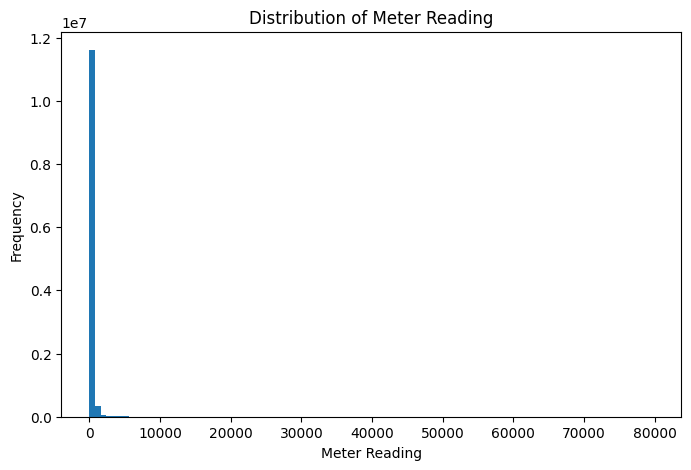

In [19]:
plt.figure(figsize=(8,5))
plt.hist(df_full['meter_reading'], bins=100)
plt.title('Distribution of Meter Reading')
plt.xlabel('Meter Reading')
plt.ylabel('Frequency')
plt.show()

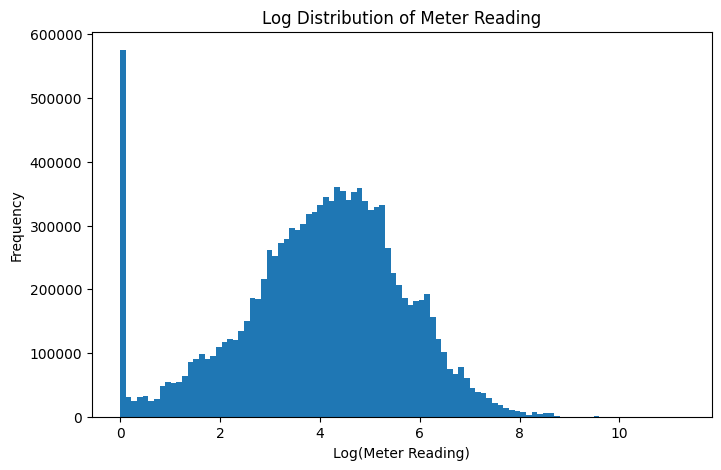

In [20]:
plt.figure(figsize=(8,5))
plt.hist(
    np.log1p(df_full['meter_reading']),
    bins=100
)

plt.title('Log Distribution of Meter Reading')
plt.xlabel('Log(Meter Reading)')
plt.ylabel('Frequency')
plt.show()

Histogram meter_reading menunjukkan distribusi yang sangat right-skewed, di mana sebagian besar observasi berada pada nilai konsumsi energi rendah dan hanya sedikit observasi memiliki nilai sangat tinggi. Untuk memahami pola distribusi secara lebih jelas, dilakukan visualisasi menggunakan transformasi logaritmik (log1p) pada tahap eksplorasi data. Hasil visualisasi menunjukkan distribusi yang lebih menyebar dan stabil, sehingga mengindikasikan bahwa transformasi log layak dipertimbangkan pada tahap preprocessing untuk meningkatkan performa model.

### Distribusi Weather

In [21]:
weather_cols = [
    'air_temperature',
    'dew_temperature',
    'wind_speed',
    'sea_level_pressure'
]

df_full[weather_cols].describe()

,air_temperature,dew_temperature,wind_speed,sea_level_pressure
count,1.201358e+07,1.201182e+07,1.199412e+07,1.104253e+07
mean,1.600965e+01,8.334991e+00,3.559324e+00,1.016408e+03
std,1.039774e+01,9.836796e+00,2.317835e+00,7.035792e+00
min,-2.890000e+01,-3.500000e+01,0.000000e+00,9.682000e+02
25%,8.900000e+00,1.100000e+00,2.100000e+00,1.012100e+03
50%,1.670000e+01,9.400000e+00,3.100000e+00,1.016500e+03
75%,2.390000e+01,1.610000e+01,4.600000e+00,1.020700e+03
max,4.720000e+01,2.610000e+01,1.900000e+01,1.045500e+03


Statistik deskriptif variabel cuaca menunjukkan bahwa dataset mencakup kondisi cuaca yang cukup beragam. air_temperature memiliki median sekitar 16,7°C dengan rentang dari −28,9°C hingga 47,2°C, yang menunjukkan data berasal dari berbagai kondisi iklim, termasuk wilayah dingin dan panas. dew_temperature memiliki median 9,4°C yang menggambarkan variasi kelembapan udara. Sementara itu, wind_speed cenderung rendah dengan median sekitar 3,1, dan sea_level_pressure relatif stabil di sekitar 1016 hPa. Temuan ini menunjukkan bahwa data cuaca masih sangat heterogen dan belum sepenuhnya merepresentasikan kondisi iklim tropis seperti Indonesia, sehingga pada tahap selanjutnya akan dipertimbangkan filtering berdasarkan karakteristik iklim Indonesia dengan dukungan literatur terkait.

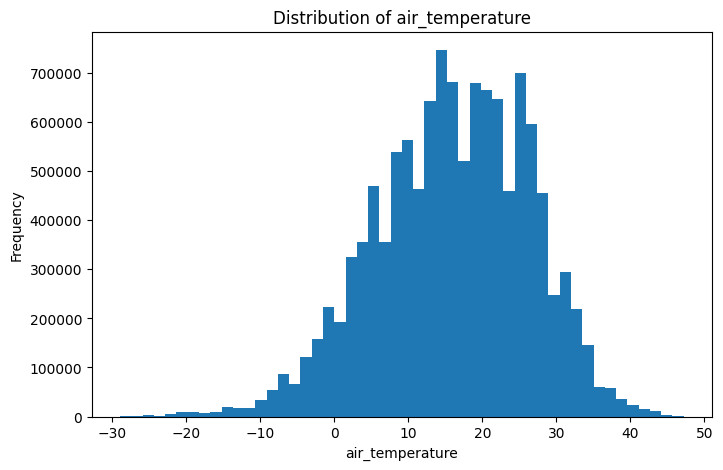

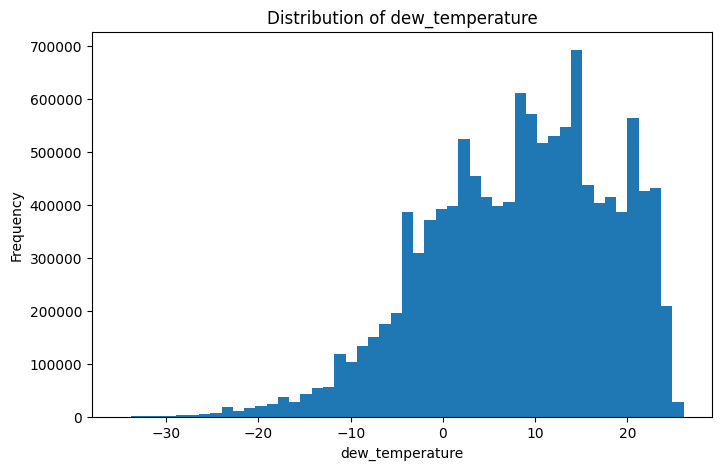

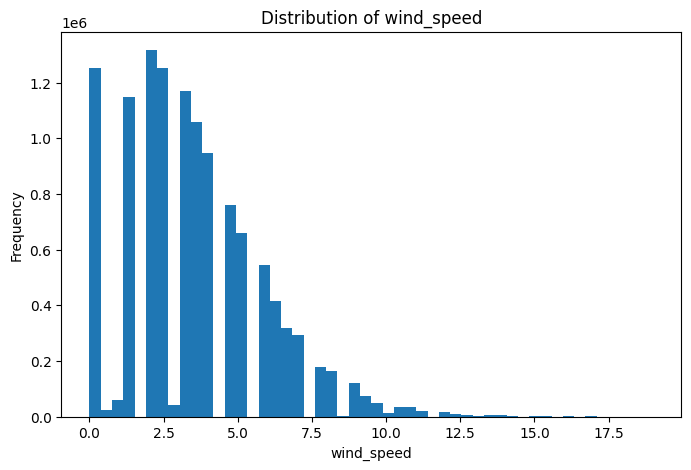

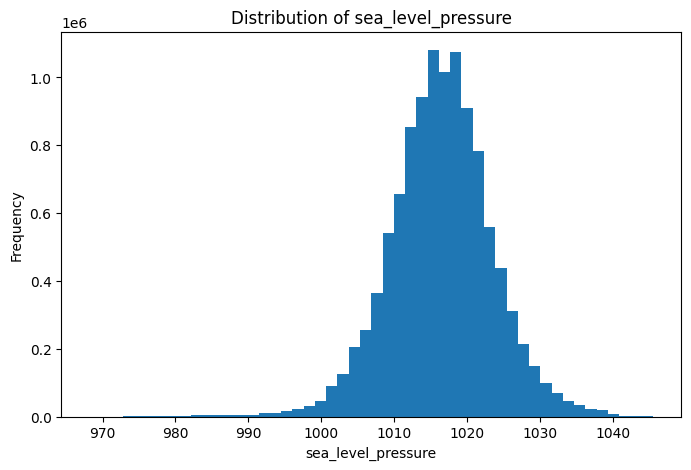

In [22]:
for col in weather_cols:

    plt.figure(figsize=(8,5))

    plt.hist(
        df_full[col].dropna(),
        bins=50
    )

    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    plt.show()

Distribusi variabel cuaca menunjukkan pola yang cukup beragam antar fitur. air_temperature memiliki distribusi mendekati normal dengan konsentrasi terbesar pada kisaran suhu sedang (sekitar 10–30°C), namun masih terdapat nilai ekstrem hingga suhu negatif, yang mengindikasikan bahwa dataset mencakup wilayah dengan iklim non-tropis. dew_temperature menunjukkan pola yang relatif serupa dan cenderung terkonsentrasi pada suhu positif, menandakan variasi tingkat kelembapan udara pada berbagai kondisi lingkungan. Variabel wind_speed memiliki distribusi right-skewed, di mana mayoritas kecepatan angin berada pada nilai rendah hingga sedang, sedangkan kecepatan tinggi hanya muncul pada sebagian kecil observasi. Sementara itu, sea_level_pressure terlihat relatif stabil dan mendekati distribusi normal dengan pusat nilai di sekitar 1010–1020 hPa, menunjukkan variasi tekanan udara yang tidak terlalu ekstrem.

### Building Type

In [23]:
df_full['primary_use'].value_counts()

primary_use
Education                        4597256
Office                           2310203
Entertainment/public assembly    1511295
Public services                  1320045
Lodging/residential              1229082
Other                             210764
Parking                           187447
Healthcare                        184345
Warehouse/storage                 103077
Retail                             96618
Manufacturing/industrial           85216
Services                           78951
Technology/science                 45275
Food sales and service             43826
Utility                            32476
Religious worship                  25034
Name: count, dtype: int64

Distribusi primary_use menunjukkan bahwa konsumsi energi didominasi oleh bangunan pendidikan (Education), diikuti kantor (Office), hiburan/fasilitas publik (Entertainment/Public Assembly), layanan publik (Public Services), dan hunian/penginapan (Lodging/Residential). Hal ini menunjukkan bahwa dataset lebih banyak merepresentasikan bangunan dengan aktivitas operasional tinggi dan penggunaan listrik rutin. Sementara itu, kategori seperti Religious worship, Utility, dan Food sales and service memiliki jumlah observasi yang relatif kecil. Pada tahap selanjutnya, distribusi ini akan menjadi dasar evaluasi relevansi jenis bangunan terhadap konteks Indonesia serta pertimbangan apakah kategori tertentu perlu dipertahankan atau disederhanakan agar analisis lebih representatif.

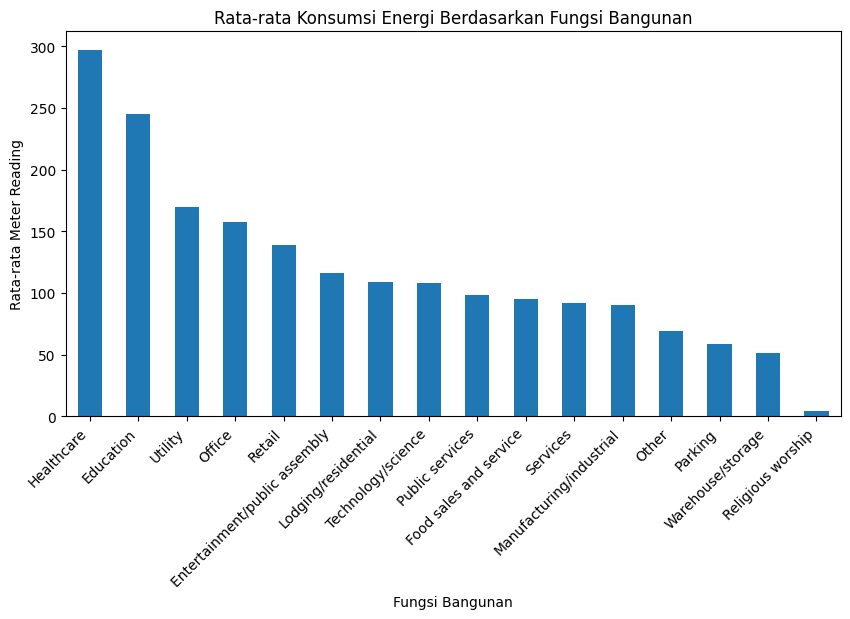

In [24]:
energy_by_use = (
    df_full
    .groupby("primary_use")["meter_reading"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
energy_by_use.plot(kind="bar")
plt.title("Rata-rata Konsumsi Energi Berdasarkan Fungsi Bangunan")
plt.xlabel("Fungsi Bangunan")
plt.ylabel("Rata-rata Meter Reading")
plt.xticks(rotation=45, ha="right")
plt.show()

Rata-rata konsumsi energi berdasarkan fungsi bangunan menunjukkan adanya perbedaan pola penggunaan listrik antar kategori bangunan. Kategori Healthcare memiliki rata-rata konsumsi energi tertinggi, diikuti Education, Utility, dan Office, yang mengindikasikan kebutuhan listrik yang relatif besar untuk mendukung aktivitas operasional, seperti pendingin ruangan, pencahayaan, perangkat elektronik, maupun layanan pendukung lainnya. Sementara itu, kategori seperti Religious worship, Warehouse/storage, dan Parking memiliki rata-rata konsumsi energi yang lebih rendah, yang kemungkinan dipengaruhi oleh intensitas penggunaan bangunan yang tidak berlangsung secara penuh sepanjang waktu.

### Pola Waktu

In [25]:
df_full['timestamp'] = pd.to_datetime(df_full['timestamp'])

In [26]:
df_full['hour'] = df_full['timestamp'].dt.hour
df_full['dayofweek'] = df_full['timestamp'].dt.day_name()
df_full['month'] = df_full['timestamp'].dt.month_name()

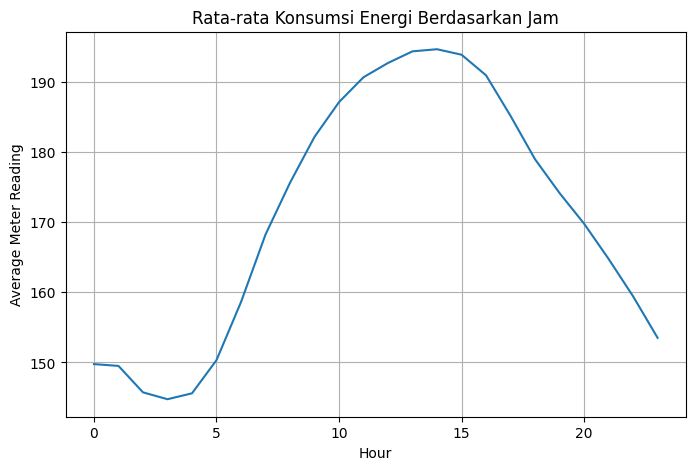

In [27]:
hourly_pattern = (
    df_full
    .groupby('hour')['meter_reading']
    .mean()
)

plt.figure(figsize=(8,5))

plt.plot(hourly_pattern)

plt.title('Rata-rata Konsumsi Energi Berdasarkan Jam')
plt.xlabel('Hour')
plt.ylabel('Average Meter Reading')

plt.grid(True)
plt.show()

Peningkatan konsumsi pada siang hingga sore kemungkinan berkaitan dengan tingginya aktivitas bangunan, terutama pada gedung pendidikan, kantor, dan layanan publik yang mendominasi dataset.

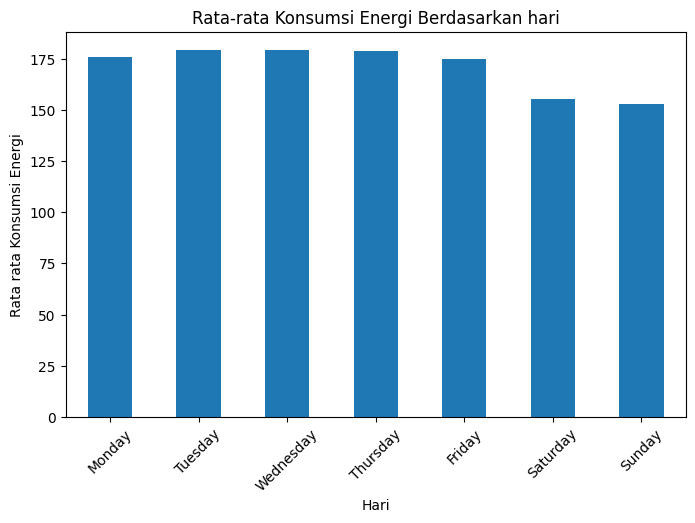

In [28]:
day_order = [
    'Monday','Tuesday','Wednesday',
    'Thursday','Friday',
    'Saturday','Sunday'
]

daily_pattern = (
    df_full
    .groupby('dayofweek')['meter_reading']
    .mean()
    .reindex(day_order)
)

plt.figure(figsize=(8,5))

daily_pattern.plot(kind='bar')

plt.title('Rata-rata Konsumsi Energi Berdasarkan hari')
plt.xlabel('Hari')
plt.ylabel('Rata rata Konsumsi Energi')

plt.xticks(rotation=45)
plt.show()

Rata-rata konsumsi energi berdasarkan hari menunjukkan pola yang relatif stabil pada hari kerja (Senin–Jumat), dengan konsumsi energi cenderung lebih tinggi pada Selasa hingga Kamis. Sementara itu, terjadi penurunan konsumsi energi pada akhir pekan (Sabtu dan Minggu). Pola ini mengindikasikan bahwa aktivitas operasional bangunan memengaruhi penggunaan listrik, di mana konsumsi energi lebih tinggi pada hari kerja akibat aktivitas pendidikan, perkantoran, dan layanan publik, sedangkan akhir pekan menunjukkan aktivitas yang relatif lebih rendah.

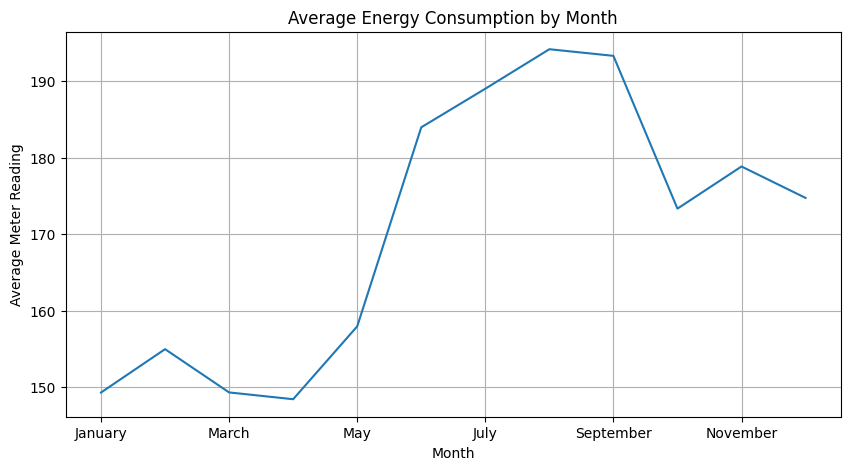

In [29]:
month_order = [
    'January','February','March',
    'April','May','June',
    'July','August','September',
    'October','November','December'
]

monthly_pattern = (
    df_full
    .groupby('month')['meter_reading']
    .mean()
    .reindex(month_order)
)

plt.figure(figsize=(10,5))

monthly_pattern.plot(kind='line')

plt.title('Average Energy Consumption by Month')
plt.xlabel('Month')
plt.ylabel('Average Meter Reading')

plt.grid(True)
plt.show()

Pola konsumsi energi berdasarkan bulan menunjukkan adanya variasi musiman (seasonality) sepanjang tahun. Konsumsi energi relatif lebih rendah pada awal tahun, khususnya sekitar Januari–April, kemudian mulai meningkat sejak pertengahan tahun dan mencapai puncak pada sekitar Agustus–September. Setelah itu, konsumsi energi kembali mengalami penurunan pada akhir tahun. Pola ini mengindikasikan bahwa penggunaan energi kemungkinan dipengaruhi oleh faktor musiman, seperti perubahan kondisi cuaca, kebutuhan pendinginan bangunan, maupun tingkat aktivitas operasional pada periode tertentu.

### Korelasi

In [30]:
numeric_cols = [
    'meter_reading',
    'floor_count',
    'square_feet',
    'air_temperature',
    'dew_temperature',
    'wind_speed',
    'sea_level_pressure'
]

corr = df_full[numeric_cols].corr()

corr

: 

Hasil korelasi menunjukkan bahwa square_feet memiliki hubungan positif sedang terhadap meter_reading (0,55), yang mengindikasikan bahwa bangunan dengan ukuran lebih besar cenderung memiliki konsumsi energi lebih tinggi. Sementara itu, variabel cuaca seperti air_temperature, dew_temperature, wind_speed, dan sea_level_pressure menunjukkan korelasi linear yang relatif lemah terhadap konsumsi energi. Hal ini mengindikasikan bahwa pengaruh cuaca terhadap konsumsi energi kemungkinan tidak bersifat langsung atau linear, melainkan dipengaruhi kombinasi faktor lain seperti waktu operasional, jenis bangunan, dan karakteristik lingkungan. Selain itu, terlihat korelasi tinggi antara air_temperature dan dew_temperature (0,76), yang menunjukkan adanya keterkaitan kuat antara suhu udara dan kelembapan.

## Pre-Processing

### Filtering Relevansi Indonesia

In [ ]:
df_full['air_temperature'].quantile(
    [0.01,0.05,0.10,0.25,0.50,0.75,0.90,0.95,0.99]
)

0.01   -10.000000
0.05    -1.700000
0.10     2.200000
0.25     8.900000
0.50    16.700001
0.75    23.900000
0.90    28.900000
0.95    31.700001
0.99    37.200001
Name: air_temperature, dtype: float32

In [ ]:
indo_mask = df_full['air_temperature'].between(15, 40)

print("Before :", len(df_full))
print("After  :", indo_mask.sum())
print("Remain :", round(
    indo_mask.mean()*100, 2
), "%")

Before : 12060910
After  : 6739305
Remain : 55.88 %


In [ ]:
df_full = df_full[
    df_full['air_temperature']
    .between(15, 40)
].copy()

print(df_full.shape)

(6739305, 19)


Untuk meningkatkan relevansi dataset terhadap konteks bangunan di Indonesia, dilakukan filtering pada variabel air_temperature dengan rentang 15–40°C. Pemilihan batas suhu ini didasarkan pada kombinasi literatur BMKG dan hasil eksplorasi distribusi data (quantile analysis). Berdasarkan informasi BMKG, suhu udara ekstrem terendah di Indonesia umumnya terjadi pada wilayah dataran tinggi seperti Dieng (Jawa Tengah) dan Puncak Jaya (Papua Tengah), yang pada kondisi tertentu dapat mencapai sekitar −2°C hingga −5°C. Namun kondisi tersebut bersifat sangat lokal dan tidak merepresentasikan mayoritas wilayah Indonesia.

Selain mempertimbangkan literatur, pemilihan batas bawah juga mengacu pada distribusi data hasil eksplorasi. Analisis quantile menunjukkan bahwa median (Q50) temperatur dataset hanya sebesar 16,7°C, yang berarti sekitar 50% observasi memiliki suhu di bawah 16,7°C. Kondisi ini dinilai kurang representatif terhadap karakteristik iklim Indonesia yang didominasi wilayah tropis hangat, karena daerah dengan suhu rendah di Indonesia relatif terbatas dan hanya terjadi pada wilayah tertentu seperti pegunungan atau dataran tinggi. Oleh karena itu, dipilih batas bawah 15°C sebagai kompromi agar tetap mengakomodasi wilayah dingin Indonesia, namun sekaligus mengurangi dominasi observasi dari wilayah beriklim dingin non-Indonesia yang tidak relevan dengan tujuan penelitian. Dengan filtering ini, sekitar 55,88% observasi (±6,7 juta data) tetap dipertahankan sehingga dataset masih cukup besar untuk proses pemodelan.

In [ ]:
missing = (
    df_full.isnull()
    .mean()
    .sort_values(ascending=False) * 100
)

print(missing)

floor_count           79.002968
year_built            53.660147
cloud_coverage        41.111079
precip_depth_1_hr     12.269455
wind_direction         7.563584
sea_level_pressure     4.696864
wind_speed             0.242295
dew_temperature        0.013814
timestamp              0.000000
building_id            0.000000
meter                  0.000000
air_temperature        0.000000
site_id                0.000000
primary_use            0.000000
square_feet            0.000000
meter_reading          0.000000
hour                   0.000000
dayofweek              0.000000
month                  0.000000
dtype: float64


In [ ]:
drop_cols = [
    'wind_direction',
    'floor_count'
]

df_full.drop(
    columns=[col for col in drop_cols if col in df_full.columns],
    inplace=True
)

fill_cols = [
    'year_built',
    'cloud_coverage',
    'precip_depth_1_hr',
    'sea_level_pressure',
    'wind_speed',
    'dew_temperature'
]

for col in fill_cols:
    df_full[col] = df_full[col].fillna(
        df_full[col].median()
    )